In [9]:
import os
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import timm
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, auc)
import seaborn as sns

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

DATA_DIR       = r"C:\Users\menga\PycharmProjects\PythonProjecteffectif\data\eye_diseases"
CHECKPOINT_DIR = r"C:\Users\menga\PycharmProjects\PythonProjecteffectif\outputs\checkpoints"
FIGURES_DIR    = r"C:\Users\menga\PycharmProjects\PythonProjecteffectif\outputs\figures"

CLASSES     = ["cataract", "diabetic_retinopathy", "glaucoma", "normal"]
NUM_CLASSES = 4
IMG_SIZE    = 224
BATCH_SIZE  = 32

print("Config prête ")

Config prête 


In [10]:
val_test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

full_dataset = datasets.ImageFolder(root=DATA_DIR, transform=val_test_transforms)

total      = len(full_dataset)
train_size = int(0.70 * total)
val_size   = int(0.15 * total)
test_size  = total - train_size - val_size

_, _, test_dataset = random_split(
    full_dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Test set : {len(test_dataset)} images ")

Test set : 634 images 


In [11]:
model = timm.create_model('efficientnet_b0', pretrained=False, num_classes=NUM_CLASSES)
model.load_state_dict(torch.load(
    os.path.join(CHECKPOINT_DIR, "best_model_finetuned.pt"),
    map_location=device
))
model = model.to(device)
model.eval()

print("Meilleur modèle chargé ")

Meilleur modèle chargé 


In [12]:
all_labels  = []
all_preds   = []
all_probs   = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        probs   = torch.softmax(outputs, dim=1)
        preds   = outputs.argmax(dim=1)

        all_labels.extend(labels.numpy())
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

all_labels = np.array(all_labels)
all_preds  = np.array(all_preds)
all_probs  = np.array(all_probs)

print("Prédictions terminées ")

Prédictions terminées 


In [13]:
print("=== Rapport de classification ===\n")
print(classification_report(
    all_labels, all_preds,
    target_names=CLASSES,
    digits=4
))

# Accuracy globale
accuracy = (all_labels == all_preds).mean()
print(f"Accuracy globale : {accuracy:.4f} ({accuracy*100:.2f}%)")

=== Rapport de classification ===

                      precision    recall  f1-score   support

            cataract     0.9419    0.9529    0.9474       170
diabetic_retinopathy     1.0000    1.0000    1.0000       155
            glaucoma     0.8767    0.9078    0.8920       141
              normal     0.9441    0.9048    0.9240       168

            accuracy                         0.9416       634
           macro avg     0.9407    0.9414    0.9408       634
        weighted avg     0.9422    0.9416    0.9417       634

Accuracy globale : 0.9416 (94.16%)


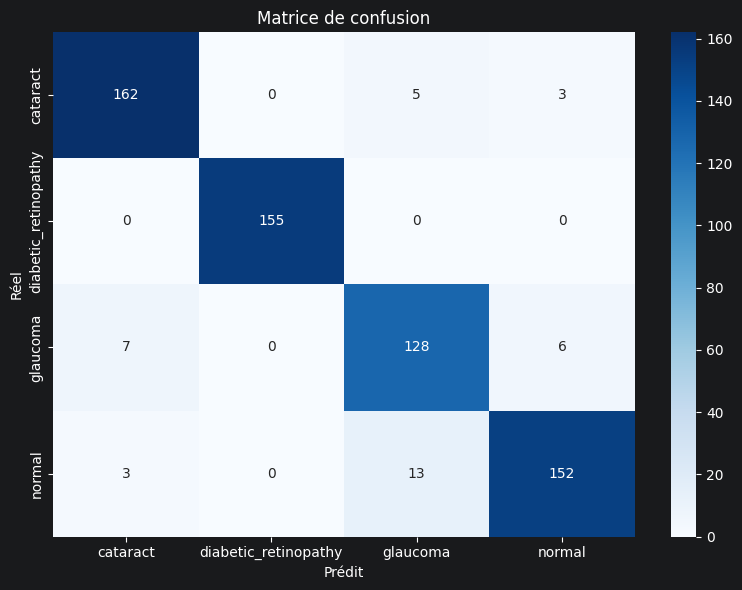

Matrice sauvegardée 


In [14]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES)
plt.title("Matrice de confusion")
plt.ylabel("Réel")
plt.xlabel("Prédit")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "matrice_confusion.png"))
plt.show()
print("Matrice sauvegardée ")

In [15]:
from sklearn.preprocessing import label_binarize

# Binariser les labels pour AUC multi-classe
labels_bin = label_binarize(all_labels, classes=[0, 1, 2, 3])

auc_score = roc_auc_score(
    labels_bin, all_probs,
    multi_class='ovr',
    average='macro'
)

print(f"AUC Score (macro) : {auc_score:.4f} ({auc_score*100:.2f}%)")

AUC Score (macro) : 0.9911 (99.11%)


In [17]:
# Charger le meilleur modèle
model.eval()

# Créer un exemple d'input (image 224x224 RGB)
dummy_input = torch.randn(1, 3, 224, 224).to(device)

# Exporter en TorchScript
scripted_model = torch.jit.trace(model, dummy_input)
scripted_model.save(
    os.path.join(CHECKPOINT_DIR, "model_scripted.pt")
)

print("Modèle exporté en TorchScript ")
print(f"Fichier : {CHECKPOINT_DIR}/model_scripted.pt")

Modèle exporté en TorchScript 
Fichier : C:\Users\menga\PycharmProjects\PythonProjecteffectif\outputs\checkpoints/model_scripted.pt


In [18]:
import requests

# Prendre une image du dataset
import os

test_image_path = r"C:\Users\menga\PycharmProjects\PythonProjecteffectif\data\eye_diseases\cataract"
test_image = os.path.join(test_image_path, os.listdir(test_image_path)[0])

print("Image testée :", test_image)

# Envoyer la requête à l'API
with open(test_image, 'rb') as f:
    response = requests.post(
        "http://127.0.0.1:5000/predict",
        files={"image": f}
    )

print("Status :", response.status_code)
print("Résultat :", response.json())

Image testée : C:\Users\menga\PycharmProjects\PythonProjecteffectif\data\eye_diseases\cataract\0_left.jpg
Status : 200
Résultat : {'confidence': 99.17, 'diagnostic': 'cataract', 'probabilites': {'cataract': 99.17, 'diabetic_retinopathy': 0.0, 'glaucoma': 0.11, 'normal': 0.71}}
